# Generalization Dataset 2

### NOTE: This notebook was originally ran using python 3.11.3

# GET EVERYTHING READY

In [1]:
# Imports
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib import ticker
import plotly.graph_objects as go

import numpy as np
import pandas as pd
import seaborn as sns
import os
import math


from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.model_selection import learning_curve

from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score, auc, brier_score_loss, pairwise_distances, silhouette_samples, precision_score, recall_score, silhouette_score

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier # Multi layer perceptron
from sklearn.tree import DecisionTreeClassifier
from sklearn.inspection import permutation_importance, PartialDependenceDisplay, partial_dependence
from sklearn.utils import shuffle
from sklearn.calibration import calibration_curve
from sklearn.tree import plot_tree
from sklearn.cross_decomposition import PLSRegression

import shap
from scipy.stats import binomtest, binom_test, ttest_ind, mannwhitneyu
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.stats import chi2_contingency
from scipy.cluster.hierarchy import fcluster
from scipy.cluster.hierarchy import dendrogram

from joblib import Parallel, delayed
import pickle

from scipy.stats import spearmanr
from sklearn.linear_model import LinearRegression



# R stuff:
%load_ext rpy2.ipython

# Settings
sns.set_theme(style="whitegrid")
sns.set_context("paper", font_scale=1.8, rc={"lines.linewidth": 2.5,"lines.markersize": 8})


# FITTING FUNCTION
# --------------------------------------------------------
def exponential_decay(x, asymp_to, improvement, alpha):
    return asymp_to + improvement * np.exp(-alpha * x)

filename = u'main_task_data_GD2.csv'

In [2]:
def compute_trend_features(values):
    # Infer time points based on length
    time = np.arange(len(values)).reshape(-1, 1)  # [0, 1, 2, ..., N-1]
    values = np.array(values)

    # Linear Regression Slope
    model = LinearRegression().fit(time, values)
    slope = model.coef_[0]  # Extract slope

    # Spearman Correlation
    spearman_corr, _ = spearmanr(time.flatten(), values)

    return slope, spearman_corr

def compute_burstiness(irt):
    """Compute burstiness measure (b) for a sequence of inter-response times (IRT)."""
    mu = np.mean(irt)
    sigma = np.std(irt)
    
    if mu + sigma == 0:  # Avoid division by zero
        print(f"mu + sigma is zero for irt: {irt}")
        return np.nan
    
    return (sigma - mu) / (sigma + mu)


# Read and parse data

In [3]:
# Load data from CSV
IPI_df = pd.read_csv('IPI_data_GD2.csv')
main_data_df = IPI_df.copy()
df = pd.read_csv(filename)
demographic_data = pd.read_csv('demographic_data_GD2.csv')

Block_Time = 45 # each block is 45 seconds
agg_dict = {
    'RT': ['count', 'first'],
    'IPI_abs_diff': 'mean',
}
# create a column of one raw per sub per trial:
trial_level_df = IPI_df.groupby(['subID', 'run', 'trial', 'outcome', 'devaluation_ratio']).agg(agg_dict).reset_index()
flattened_columns = []
for col in trial_level_df.columns:
    if isinstance(col, tuple):
        var_name, agg_name = col
        # Check if the variable had multiple aggregations
        if isinstance(agg_dict.get(var_name), list) and len(agg_dict[var_name]) > 1:
            flattened_columns.append(f"{var_name}_{agg_name}")
        else:
            flattened_columns.append(var_name)
    else:
        flattened_columns.append(col)
trial_level_df.columns = flattened_columns

trial_level_df.rename(columns={'RT_count': 'n_resp', 'RT_first': 'first_RT'}, inplace=True)
trial_level_df['resp_rate'] = trial_level_df['n_resp'] / Block_Time

In [4]:
features_data = pd.DataFrame()
trial_level_df.groupby('subID')['devaluation_ratio'].first()
subID = 2
for subID in main_data_df['subID'].unique():
    data_subset = main_data_df[main_data_df['subID'] == subID].reset_index(drop=True)
    data_subset = data_subset[data_subset['run'] == 1].reset_index(drop=True)

    trial_level_df_subset = trial_level_df[trial_level_df['subID'] == subID].reset_index(drop=True)
    trial_level_df_subset = trial_level_df_subset[trial_level_df_subset['run'] == 1].reset_index(drop=True)

    resp_rate_trial_mean = trial_level_df_subset['resp_rate'].mean()
    resp_rate_trial_std = trial_level_df_subset['resp_rate'].std()

    # Sum pairs of consecutive trials (to have combined each pair of different stimuli)
    resp_pairs_sum = pd.Series(index=trial_level_df_subset.index[::2],
                            data=[trial_level_df_subset["resp_rate"].iloc[i:i+2].sum() for i in range(0, len(trial_level_df_subset)-1, 2)])

    resp_pairs_sum_std = resp_pairs_sum.std() ###

    RTs_first_resp_mean = (trial_level_df_subset.first_RT/1000).mean() ###
    RTs_first_resp_std = (trial_level_df_subset.first_RT/1000).std() ###

    # turns out isCorrectResp CANNOT be calculated form the data, because wrong key presses have NOT BEEN RECORDED!

    # compute trend features on resp_pairs_sum:
    resp_pairs_sum_slope, resp_pairs_sum_spearman_corr = compute_trend_features(resp_pairs_sum.values) ### ###

    resp_time_diff_mean = (data_subset['IPI']/1000).mean() ###
    resp_time_diff_std = (data_subset['IPI']/1000).std() ###

    volatility = (data_subset['IPI_abs_diff']/1000).mean() ###

    # right_vs_left isn't possible becuase silver was always left and fold always right...
    gold_vs_silver = trial_level_df_subset.groupby(['outcome']).resp_rate.mean()['gold'] - trial_level_df_subset.groupby(['outcome']).resp_rate.mean()['silver'] ###

    # resp_time_diff_after_reward_mean and resp_time_diff_after_reward_std might be problematic so not getting them for now (if these was no reward in a trial I will not be able to associate all other to which trials it is in...)
    # Same for post_reward_RT_mean and post_reward_RT_std

    run_burstiness = compute_burstiness(data_subset['IPI']) ###


    # Now add the features to the features data:
    sub_features_data = pd.DataFrame({'subID': [subID], 'resp_rate_trial_mean': [resp_rate_trial_mean], 'resp_rate_trial_std': [resp_rate_trial_std], 
                                'resp_pairs_sum_std': [resp_pairs_sum_std], 'RTs_first_resp_mean': [RTs_first_resp_mean], 'RTs_first_resp_std': [RTs_first_resp_std],
                                # 'isCorrectResp_prop_mean': [isCorrectResp_prop_mean], 'isCorrectResp_prop_std': [isCorrectResp_prop_std],
                                'resp_pairs_sum_slope': [resp_pairs_sum_slope], 'resp_pairs_sum_spearman_corr': [resp_pairs_sum_spearman_corr],
                                'resp_time_diff_mean': [resp_time_diff_mean], 'resp_time_diff_std': [resp_time_diff_std], 'volatility': [volatility], #
                                'gold_vs_silver': [gold_vs_silver],
                                # 'right_vs_left': [right_vs_left], 
                                # 'resp_time_diff_after_reward_mean': [resp_time_diff_after_reward_mean], 'resp_time_diff_after_reward_std': [resp_time_diff_after_reward_std], 
                                # 'post_reward_RT_mean': [post_reward_RT_mean], 'post_reward_RT_std': [post_reward_RT_std],
                                'run_burstiness': [run_burstiness]})
    
    # # Now add the features to the features data:
    # sub_features_data = pd.DataFrame({'subID': [subID], 'resp_rate_trial_mean': [resp_rate_trial_mean], 'resp_rate_trial_std': [resp_rate_trial_std], 
    #                             'RTs_first_resp_mean': [RTs_first_resp_mean], 'RTs_first_resp_std': [RTs_first_resp_std],
    #                             # 'isCorrectResp_prop_mean': [isCorrectResp_prop_mean], 'isCorrectResp_prop_std': [isCorrectResp_prop_std],
    #                             # 'resp_pairs_sum_slope': [resp_pairs_sum_slope], 'resp_pairs_sum_spearman_corr': [resp_pairs_sum_spearman_corr],
    #                             # 'resp_time_diff_mean': [resp_time_diff_mean], 'resp_time_diff_std': [resp_time_diff_std], 
    #                             'volatility': [volatility], #
    #                             'gold_vs_silver': [gold_vs_silver],
    #                             # 'right_vs_left': [right_vs_left], 
    #                             # 'resp_time_diff_after_reward_mean': [resp_time_diff_after_reward_mean], 'resp_time_diff_after_reward_std': [resp_time_diff_after_reward_std], 
    #                             # 'post_reward_RT_mean': [post_reward_RT_mean], 'post_reward_RT_std': [post_reward_RT_std],
    #                             'run_burstiness': [run_burstiness]})

    features_data = pd.concat([features_data, sub_features_data])

features_data = features_data.reset_index(drop=True)
Dependent_vars = trial_level_df.groupby('subID')['devaluation_ratio'].first().reset_index()
Dependent_vars['devaluation_ratio_binary'] = Dependent_vars['devaluation_ratio'].apply(lambda x: 1 if x < 0.648 else 0) # 1 is habitual
Dependent_vars['devaluation_ratio_binary_median'] = Dependent_vars['devaluation_ratio'].apply(lambda x: 1 if x < Dependent_vars['devaluation_ratio'].median() else 0) # 1 is habitual

Continious


n=164, mean=0.692, std=0.231
Total n=164, mean=0.692, std=0.231

RUNNING NESTED LOOCV ON TRAINING SET

n=164, mean=0.692, std=0.230
Total n=164, mean=0.692, std=0.230


Outer CV folds: 100%|██████████| 164/164 [00:12<00:00, 12.90it/s]



NESTED LOOCV REGRESSION RESULTS:
R²: 0.0241
RMSE: 0.2272
MAE: 0.2078
Pearson r: 0.1575 (p=0.0440)
Spearman r: 0.2278 (p=0.0034)


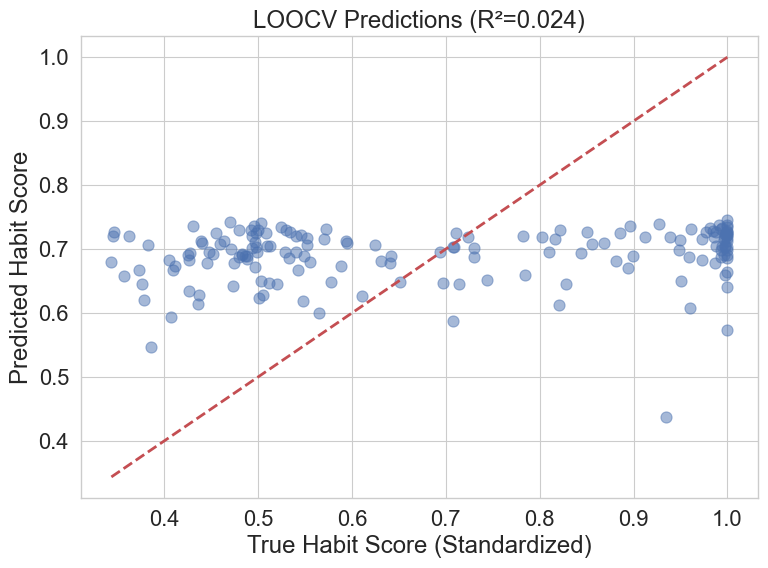


CONFIGURATION SELECTION FREQUENCY:


Model selection frequency:
  ElasticNet: 160/164 folds (97.6%)
  Ridge: 2/164 folds (1.2%)
  SVR_rbf: 2/164 folds (1.2%)

Number of features selected:
  all features: 164/164 folds (100.0%)

Most common configurations:
  ElasticNet_nfeatall_alpha0.1_l1_ratio0.5: 160/164 folds (97.6%)
  Ridge_nfeatall_alpha10.0: 2/164 folds (1.2%)
  SVR_rbf_nfeatall_C0.1_kernelrbf_gamma0.01: 2/164 folds (1.2%)

RECOMMENDED CONFIGURATION FOR EXTERNAL DATA:
Model: ElasticNet
Number of features: all
Hyperparameters: {'alpha': 0.1, 'l1_ratio': 0.5, 'max_iter': 5000}


In [ ]:
from collections import Counter
from sklearn.feature_selection import SelectKBest, f_classif
from joblib import Parallel, delayed
from itertools import product
from tqdm import tqdm
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import KFold
from scipy.stats import pearsonr, spearmanr
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_regression  # CHANGE THIS


# ============================================
# PREPARE DATA
# ============================================
block_df = features_data.copy()
# merge outcome
block_df = block_df.merge(Dependent_vars[["subID", "devaluation_ratio"]], on="subID", how="inner").reset_index(drop=True)
y = block_df["devaluation_ratio"].astype(float)
subjects = block_df["subID"].reset_index(drop=True)
drop_cols = {"subID", "devaluation_ratio"}
X_cont = block_df.drop(columns=list(drop_cols))
print(f"n={len(y)}, mean={y.mean():.3f}, std={y.std():.3f}")

# Convert to arrays
X_cont_arr = X_cont.values
y_arr = np.asarray(y).astype(float)

# Convert to arrays FIRST (before splitting)
X_cont_arr_full = X_cont.values
y_arr_full = np.asarray(y).astype(float)  # Keep as float for regression
subjects_arr_full = subjects.values

print(f"Total n={len(y)}, mean={y.mean():.3f}, std={y.std():.3f}")

# ============================================
# TRAINING SET (for LOOCV nested CV)
# ============================================
X_cont_arr = X_cont_arr_full
# get the relevant df X_cont :
X_cont_main_tr_set = pd.DataFrame(X_cont_arr, columns=X_cont.columns)
y_arr = y_arr_full
subjects = pd.Series(subjects_arr_full).reset_index(drop=True)  # Convert back to Series for compatibility

# ============================================
# YOUR EXISTING LOOCV CODE STARTS HERE
# ============================================
print(f"\n{'='*60}")
print("RUNNING NESTED LOOCV ON TRAINING SET")
print(f"{'='*60}\n")
print(f"n={len(y_arr)}, mean={y_arr.mean():.3f}, std={y_arr.std():.3f}")



# Models to test + # features + settings:
# ----------------------------------------

models_to_test = {
    # 'LinearRegression': {'model': LinearRegression, 'params': {}},  # No regularization
    'Ridge': {'model': Ridge, 'params': {'alpha': [0.1, 1.0, 10.0]}},
    'Lasso': {'model': Lasso, 'params': {'alpha': [0.1, 1.0, 10.0], 'max_iter': [5000]}},
    'ElasticNet': {'model': ElasticNet, 'params': {'alpha': [0.1, 1.0, 10.0], 'l1_ratio': [0.5], 'max_iter': [5000]}},  # Only true elastic net
    'SVR_rbf': {'model': SVR, 'params': {'C': [0.1, 1, 10], 'kernel': ['rbf'], 'gamma': ['scale', 0.01, 0.1]}},
    # 'RandomForest': {'model': RandomForestRegressor, 'params':  {'max_depth': [5, 10], 'min_samples_leaf': [5, 10]}},
    # 'RandomForest': {'model': RandomForestRegressor, 'params': {'n_estimators': [50, 100], 'max_depth': [3, 5, 7, None], 'min_samples_leaf': [1, 3, 5, 10]}},
}

n_inner_folds = 10
do_PCA = True
pca_var = 0.95
measure_to_pick_model = "mse"  # or "mse"
measure_to_pick_model = "r2"  # or "mse"
measure_to_pick_model = "mae"  # or "mse"


# n_features_to_test = [3, max(2, n_features // 4), max(2, n_features // 2), max(3, int(n_features * 0.75)), n_features]
# n_features_to_test = [1, 2, 3,5,7,10,15,17, 'all']
n_features_to_test = [3,5,10,'all']
n_features_to_test = ['all']
# n_features_to_test = ['all']
# n_features_to_test = [3,5]


print(f"Total n={len(y_arr)}, mean={y_arr.mean():.3f}, std={y_arr.std():.3f}")

def _process_outer_fold(fold_idx, train_index, test_index, X_cont_arr, y_arr, 
                        subjects, models_to_test, n_features_to_test, 
                        n_inner_folds, measure_to_pick_model):
    
    configs_data_fold = {}
    
    # Split data (Outer)
    X_cont_train_Outer = X_cont_arr[train_index]
    X_cont_test_Outer = X_cont_arr[test_index]
    y_train_Outer = y_arr[train_index]
    y_test_Outer = y_arr[test_index]
    
    matching_sub = subjects.iloc[test_index[0]]

    # Inner CV - CHANGED to KFold for regression
    inner_cv = KFold(n_splits=n_inner_folds, shuffle=True, random_state=42)
    
    best_inner_score = -np.inf if measure_to_pick_model == "r2" else np.inf  # CHANGED
    best_config = None
    
    for model_name, model_dict in models_to_test.items():
        for n_feat in n_features_to_test:
            param_keys = list(model_dict['params'].keys())
            param_values = list(model_dict['params'].values())
            param_combinations = [dict(zip(param_keys, v)) for v in product(*param_values)]
            
            for params in param_combinations:
                inner_r2 = []
                inner_mse = []
                inner_mae = []
                
                for inner_train_idx, inner_test_idx in inner_cv.split(X_cont_train_Outer):  # CHANGED: removed y stratification
                    X_cont_train_Inner = X_cont_train_Outer[inner_train_idx]
                    X_cont_test_Inner = X_cont_train_Outer[inner_test_idx]
                    y_train_Inner = y_train_Outer[inner_train_idx]
                    y_test_Inner = y_train_Outer[inner_test_idx]

                    # Scale
                    scaler = StandardScaler().fit(X_cont_train_Inner)
                    X_cont_train_Inner_scaled = scaler.transform(X_cont_train_Inner)
                    X_cont_test_Inner_scaled = scaler.transform(X_cont_test_Inner)
                    
                    # # Feature selection
                    # n_features = X_cont_train_Inner_scaled.shape[1]
                    # if n_feat != "all" and n_feat < n_features:
                    #     selector = SelectKBest(f_regression, k=n_feat)
                    #     X_cont_train_Inner_scaled = selector.fit_transform(X_cont_train_Inner_scaled, y_train_Inner)
                    #     X_cont_test_Inner_scaled = selector.transform(X_cont_test_Inner_scaled)

                    # # PCA
                    # if do_PCA:
                    #     pca = PCA(n_components=pca_var).fit(X_cont_train_Inner_scaled)
                    #     X_cont_train_Inner_pca = pca.transform(X_cont_train_Inner_scaled)
                    #     X_cont_test_Inner_pca = pca.transform(X_cont_test_Inner_scaled)
                    # else:
                    #     X_cont_train_Inner_pca = X_cont_train_Inner_scaled
                    #     X_cont_test_Inner_pca = X_cont_test_Inner_scaled


                    # PCA on Inner TRAIN only (BEFORE SelectKBest)
                    if do_PCA:
                        pca = PCA(n_components=pca_var).fit(X_cont_train_Inner_scaled)
                        X_cont_train_Inner_pca = pca.transform(X_cont_train_Inner_scaled)
                        X_cont_test_Inner_pca = pca.transform(X_cont_test_Inner_scaled)
                    else:
                        X_cont_train_Inner_pca = X_cont_train_Inner_scaled
                        X_cont_test_Inner_pca = X_cont_test_Inner_scaled

                    # Feature selection (AFTER PCA)
                    n_features = X_cont_train_Inner_pca.shape[1]
                    if n_feat != "all" and n_feat < n_features:
                        selector = SelectKBest(f_regression, k=n_feat)
                        X_cont_train_Inner_pca = selector.fit_transform(X_cont_train_Inner_pca, y_train_Inner)
                        X_cont_test_Inner_pca = selector.transform(X_cont_test_Inner_pca)

                    X_train_Inner = X_cont_train_Inner_pca.copy()
                    X_test_Inner = X_cont_test_Inner_pca.copy()

                    # Train model
                    if model_name in ['SVR_rbf', 'SVR', 'LinearRegression']:  # Add any other models without random_state
                        model = model_dict['model'](**params)
                    else:
                        model = model_dict['model'](**params, random_state=42)

                    model.fit(X_train_Inner, y_train_Inner)
                    
                    # Evaluate - CHANGED metrics
                    y_test_Inner_pred = model.predict(X_test_Inner)
                    inner_r2.append(r2_score(y_test_Inner, y_test_Inner_pred))
                    inner_mse.append(mean_squared_error(y_test_Inner, y_test_Inner_pred))
                    inner_mae.append(mean_absolute_error(y_test_Inner, y_test_Inner_pred))
                
                # Average performance
                mean_inner_r2 = np.mean(inner_r2)
                mean_inner_mse = np.mean(inner_mse)
                mean_inner_mae = np.mean(inner_mae)
                
                configs_data_fold[(fold_idx, model_name, n_feat, str(params))] = {
                    'model_name': model_name,
                    'model_class': model_dict['model'],
                    'params': params,
                    'n_features': n_feat,
                    'inner_cv_r2': mean_inner_r2,
                    'inner_cv_mse': mean_inner_mse,
                    'inner_cv_mae': mean_inner_mae,
                    'inner_cv_r2_list': inner_r2,
                    'inner_cv_mse_list': inner_mse,
                    'inner_cv_mae_list': inner_mae
                }
                
                # Select best config - CHANGED
                if measure_to_pick_model == "r2" and mean_inner_r2 > best_inner_score:
                    best_inner_score = mean_inner_r2
                    best_config = {
                        'model_name': model_name,
                        'model_class': model_dict['model'],
                        'params': params,
                        'n_features': n_feat,
                        'inner_cv_r2': mean_inner_r2,
                        'inner_cv_mse': mean_inner_mse,
                        'inner_cv_mae': mean_inner_mae
                    }
                elif measure_to_pick_model == "mse" and mean_inner_mse < best_inner_score:
                    best_inner_score = mean_inner_mse
                    best_config = {
                        'model_name': model_name,
                        'model_class': model_dict['model'],
                        'params': params,
                        'n_features': n_feat,
                        'inner_cv_r2': mean_inner_r2,
                        'inner_cv_mse': mean_inner_mse,
                        'inner_cv_mae': mean_inner_mae
                    }
                elif measure_to_pick_model == "mae" and mean_inner_mae < best_inner_score:
                    best_inner_score = mean_inner_mae
                    best_config = {
                        'model_name': model_name,
                        'model_class': model_dict['model'],
                        'params': params,
                        'n_features': n_feat,
                        'inner_cv_r2': mean_inner_r2,
                        'inner_cv_mse': mean_inner_mse,
                        'inner_cv_mae': mean_inner_mae
                    }
    
    # Retrain on outer fold (same as before, but remove predict_proba calls)
    scaler = StandardScaler().fit(X_cont_train_Outer)
    X_cont_train_Outer_scaled = scaler.transform(X_cont_train_Outer)
    X_cont_test_Outer_scaled = scaler.transform(X_cont_test_Outer)
    
    # n_features_outer = X_cont_train_Outer_scaled.shape[1]
    # k_final = best_config["n_features"]
    # if k_final == "all" or k_final >= n_features_outer:
    #     X_cont_train_Outer_scaled = X_cont_train_Outer_scaled
    #     X_cont_test_Outer_scaled = X_cont_test_Outer_scaled
    # else:
    #     selector_final = SelectKBest(f_regression, k=best_config['n_features'])
    #     X_cont_train_Outer_scaled = selector_final.fit_transform(X_cont_train_Outer_scaled, y_train_Outer)
    #     X_cont_test_Outer_scaled = selector_final.transform(X_cont_test_Outer_scaled)
    
    # if do_PCA:
    #     pca = PCA(n_components=pca_var).fit(X_cont_train_Outer_scaled)
    #     X_cont_train_Outer_pca = pca.transform(X_cont_train_Outer_scaled)
    #     X_cont_test_Outer_pca = pca.transform(X_cont_test_Outer_scaled)
    # else:
    #     X_cont_train_Outer_pca = X_cont_train_Outer_scaled
    #     X_cont_test_Outer_pca = X_cont_test_Outer_scaled
        
    # PCA on Outer TRAIN only (BEFORE SelectKBest)
    if do_PCA:
        pca = PCA(n_components=pca_var).fit(X_cont_train_Outer_scaled)
        X_cont_train_Outer_pca = pca.transform(X_cont_train_Outer_scaled)
        X_cont_test_Outer_pca = pca.transform(X_cont_test_Outer_scaled)
    else:
        X_cont_train_Outer_pca = X_cont_train_Outer_scaled
        X_cont_test_Outer_pca = X_cont_test_Outer_scaled
    
    # Feature selection (AFTER PCA)
    n_features_outer = X_cont_train_Outer_pca.shape[1]
    k_final = best_config["n_features"]
    if k_final == "all" or k_final >= n_features_outer:
        X_cont_train_Outer_pca = X_cont_train_Outer_pca
        X_cont_test_Outer_pca = X_cont_test_Outer_pca
    else:
        selector_final = SelectKBest(f_regression, k=best_config['n_features'])
        X_cont_train_Outer_pca = selector_final.fit_transform(X_cont_train_Outer_pca, y_train_Outer)
        X_cont_test_Outer_pca = selector_final.transform(X_cont_test_Outer_pca)

    X_train_Outer = X_cont_train_Outer_pca.copy()
    X_test_Outer = X_cont_test_Outer_pca.copy()
    
    # Train final model
    if best_config['model_name'] in ['SVR_rbf', 'SVR', 'LinearRegression']:
        model_final = best_config['model_class'](**best_config['params'])
    else:
        model_final = best_config['model_class'](**best_config['params'], random_state=42)

    model_final.fit(X_train_Outer, y_train_Outer)

    # Predict - REMOVED predict_proba
    y_true = y_test_Outer[0]
    y_pred = model_final.predict(X_test_Outer)[0]
    
    return {
        "fold_idx": fold_idx,
        "y_true": y_true,
        "y_pred": y_pred,
        "matching_sub": matching_sub,
        "best_config": best_config,
        "configs_data_fold": configs_data_fold,
    }
# Run the Nested CV in parallel over outer folds
loo = LeaveOneOut()
outer_splits = list(loo.split(X_cont_arr))

# n_jobs=-1 uses all cores; set to an int if you want to limit it.
results = Parallel(n_jobs=-1, prefer="processes")(
    delayed(_process_outer_fold)(
        fold_idx, train_index, test_index,
        X_cont_arr, y_arr,
        subjects,
        models_to_test, n_features_to_test,
        n_inner_folds, measure_to_pick_model
    )
    for fold_idx, (train_index, test_index) in tqdm(list(enumerate(outer_splits)), total=len(outer_splits), desc="Outer CV folds")
)

# Aggregate in fold order
results = sorted(results, key=lambda d: d["fold_idx"])

# Merge configs_data from all folds
configs_data = {}
for r in results:
    configs_data.update(r["configs_data_fold"])

y_true_all = np.array([r["y_true"] for r in results], dtype=float)
y_pred_all = np.array([r["y_pred"] for r in results], dtype=float)

matching_sub_all = [r["matching_sub"] for r in results]
selected_configs = [r["best_config"] for r in results]

# ============================================
# COMPUTE FINAL METRICS
# ============================================
r2 = r2_score(y_true_all, y_pred_all)
mse = mean_squared_error(y_true_all, y_pred_all)
mae = mean_absolute_error(y_true_all, y_pred_all)
rmse = np.sqrt(mse)
pearson_r, pearson_p = pearsonr(y_true_all, y_pred_all)
spearman_r, spearman_p = spearmanr(y_true_all, y_pred_all)

print(f'\n{"="*60}')
print(f'NESTED LOOCV REGRESSION RESULTS:')
print(f'{"="*60}')
print(f'R²: {r2:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'MAE: {mae:.4f}')
print(f'Pearson r: {pearson_r:.4f} (p={pearson_p:.4f})')
print(f'Spearman r: {spearman_r:.4f} (p={spearman_p:.4f})')


# Optional: Plot predictions vs actual
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.scatter(y_true_all, y_pred_all, alpha=0.5)
plt.plot([y_true_all.min(), y_true_all.max()], 
         [y_true_all.min(), y_true_all.max()], 'r--', lw=2)
plt.xlabel('True Habit Score (Standardized)')
plt.ylabel('Predicted Habit Score')
plt.title(f'LOOCV Predictions (R²={r2:.3f})')
plt.tight_layout()
plt.show()

# ============================================
# ANALYZE CONFIGURATION STABILITY
# ============================================

print(f'\n{"============================================================"}')
print(f'CONFIGURATION SELECTION FREQUENCY:')
print(f'\n{"============================================================"}')

# Count model selections
model_counts = Counter([c['model_name'] for c in selected_configs])
print(f'\nModel selection frequency:')
for model, count in model_counts.most_common():
    print(f'  {model}: {count}/{len(selected_configs)} folds ({100*count/len(selected_configs):.1f}%)')

# Count n_features selections
nfeat_counts = Counter([c['n_features'] for c in selected_configs])
print(f'\nNumber of features selected:')
for nfeat, count in nfeat_counts.most_common():
    print(f'  {nfeat} features: {count}/{len(selected_configs)} folds ({100*count/len(selected_configs):.1f}%)')

# Most common hyperparameters
print(f'\nMost common configurations:')
config_strings = [f"{c['model_name']}_nfeat{c['n_features']}_" + "_".join([f"{k}{v}" for k, v in c['params'].items() if k not in ['probability', 'solver', 'max_iter', 'random_state']]) for c in selected_configs]
config_counts = Counter(config_strings)
for config, count in config_counts.most_common(5):
    print(f'  {config}: {count}/{len(selected_configs)} folds ({100*count/len(selected_configs):.1f}%)')

# ============================================
# DETERMINE "BEST" CONFIGURATION FOR DEPLOYMENT
# ============================================
# Use most common configuration
most_common_model = model_counts.most_common(1)[0][0]
most_common_nfeat = nfeat_counts.most_common(1)[0][0]

# For this model, find most common hyperparameters
configs_for_model = [c for c in selected_configs if c['model_name'] == most_common_model]

# Get most common hyperparameter values
best_deployment_config = {
    'model_name': most_common_model,
    'n_features': most_common_nfeat,
    'params': {}
}

for key in configs_for_model[0]['params'].keys():
    param_values = [c['params'][key] for c in configs_for_model]
    best_deployment_config['params'][key] = Counter(param_values).most_common(1)[0][0]

print(f'\n{"="*60}')
print(f'RECOMMENDED CONFIGURATION FOR EXTERNAL DATA:')
print(f'{"="*60}')
print(f'Model: {best_deployment_config["model_name"]}')
print(f'Number of features: {best_deployment_config["n_features"]}')
print(f'Hyperparameters: {best_deployment_config["params"]}')

